In [1]:
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pygmsh
import gmsh
import capytaine as cpt
from scipy.io import loadmat

import wecopttool as wot

from jax import debug

import logging 
logging.getLogger().setLevel(logging.INFO)

In [2]:
# Frequency object
wavefreq    = 1/8 # Hz
f1          = wavefreq
nfreq       = 10
freq        = wot.frequency(f1, nfreq, False) # False -> no zero frequency

# Define waves object
amplitude   = 0.5 # m
phase       = 0 # degrees
wavedir     = 0 # degrees
waves       = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

In [3]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop    = 0.1
flapCenterDistanceApart = 1.44
flapWidth   = 0.76
flapHeight = 0.58
flapDraft  = 0.59 # 0.53 is based on matching impedance, 0.59 for fully submerged
cgHeightAboveHinge = 0.17
flap1CG     = [-flapCenterDistanceApart/2, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin
flap2CG     = [flapCenterDistanceApart/2, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin

platformFrameLength      = 1.44 
platformFrameThickness = 0.05
platformFrameWidth = 1.06
platformFrameTopDepth = 0.53 + 0.1
platformCG      = [0, 0, -0.8]
cutoutWidth         = platformFrameWidth - 2*platformFrameThickness
cutoutLength        = platformFrameLength - 2*platformFrameThickness

fullWidth = 1.63
columnsRadius       = 0.1
columnsDraft        = 0.53 + 0.1 + 0.4
columnsXY           = [flapCenterDistanceApart/2, fullWidth/2-columnsRadius]

daqLength = 0.72
daqWidth = 0.6
daqHeight = 0.2
daqTopDepth = 0.53 + 0.1 + 0.05

#%% Define the meshes
# Define the meshes
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', 0.3)
    platform = geom.add_box([-platformFrameLength/2, -platformFrameWidth/2, -platformFrameTopDepth-platformFrameThickness], [platformFrameLength,platformFrameWidth,platformFrameThickness])
    cutout = geom.add_box([-cutoutLength/2, -cutoutWidth/2, -platformFrameTopDepth-platformFrameThickness], [cutoutLength,cutoutWidth,platformFrameThickness])
    cyl1 = geom.add_cylinder([-columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl2 = geom.add_cylinder([-columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl3 = geom.add_cylinder([columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl4 = geom.add_cylinder([columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    DAQ = geom.add_box([-daqLength/2, -daqWidth/2, -daqTopDepth-daqHeight], [daqLength,daqWidth,daqHeight])
    platformFrame = geom.boolean_difference(platform,cutout)
    geom.boolean_union([platformFrame,DAQ,cyl1,cyl2,cyl3,cyl4])
    platformMesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [-flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap2 = geom.add_polygon(
            [[flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap2,[0,flapWidth,0])
    flap2Mesh = geom.generate_mesh()


# define the floating body
m1 = 189.8
J1 = 30
# platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform')
platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform', center_of_mass=platformCG)
platform.add_all_rigid_body_dofs()
platform.rotation_center = platform.center_of_mass
# platform.inertia_matrix = platform.compute_rigid_body_inertia()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m1,m1,m1,J1,J1,J1]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(platform.dofs),
                                    'radiating_dof': list(platform.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
platform.inertia_matrix = rigid_inertia_matrix_xr
platform.hydrostatic_stiffness = platform.immersed_part().compute_hydrostatic_stiffness()
print(platform.hydrostatic_stiffness)

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)
flap1.add_all_rigid_body_dofs()
#flap1.show_matplotlib()
flap1.rotation_center = flap1.center_of_mass
m2 = 23.1
J2 = 1.19
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m2,m2,m2,J2,J2,J2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap1.dofs),
                                    'radiating_dof': list(flap1.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap1.inertia_matrix = rigid_inertia_matrix_xr
flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()

# define the floating body
flap2 = cpt.FloatingBody(mesh=flap2Mesh, name=f'flap2', center_of_mass=flap2CG)
flap2.add_all_rigid_body_dofs()
flap2.rotation_center = flap2.center_of_mass
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m2,m2,m2,J2,J2,J2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap2.dofs),
                                    'radiating_dof': list(flap2.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap2.inertia_matrix = rigid_inertia_matrix_xr
flap2.hydrostatic_stiffness = flap2.immersed_part().compute_hydrostatic_stiffness()

INFO:capytaine.io.meshio:Stored 2772 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_0"), lid_mesh=None, dofs={}, center_of_mass=[ 0.   0.  -0.8], name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_

<xarray.DataArray 'hydrostatic_stiffness' (influenced_dof: 6, radiating_dof: 6)> Size: 288B
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.15534962e+03,
         1.31679650e-03,  3.27114022e-03,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.31679650e-03,
         9.32003611e+02,  6.29827066e-02,  1.07947688e-01],
       [ 0.00000000e+00,  0.00000000e+00,  3.27114022e-03,
         6.29827066e-02,  9.40275994e+02, -3.16072097e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])
Coordinates:
  * influenced_dof  (influenced_dof) <U5 120B 'Surge' 'Sway' ... 'Pitch' 'Yaw'
  * radiating_dof   (radiating_dof) <U5 120B 'Surge' 'Sway' ... 'Pitch' 'Yaw'


INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_7"), lid_mesh=None, dofs={}, center_of_mass=[ 0.72  0.   -0.42], name="flap2").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="flap2").center_of_mass = [ 0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap2").center_of_mass = [ 0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="flap2").center_of_mass = [ 0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:Clipping flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_7 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


In [4]:
# run BEM calculations
bem_data_file = 'foswec_WOT.nc'

if os.path.exists(bem_data_file):
    bem_data = wot.read_netcdf(bem_data_file)
else:
    bem_data = wot.run_bem(allbodies, freq, depth=2)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(bem_data_file, bem_data) # saves BEM data to file

body_coord = bem_data.coords["body_name"].values
com = np.vstack([b.center_of_mass for b in [platform, flap1, flap2]])
cob = np.vstack([b.center_of_buoyancy for b in [platform, flap1, flap2]])
volumes = np.array([b.immersed_part().volume for b in [platform, flap1, flap2]], dtype=float)

bem_data["center_of_mass"] = xr.DataArray(com, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
bem_data["center_of_buoyancy"] = xr.DataArray(cob, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
bem_data["volume"] = xr.DataArray(volumes, dims=("bod",), coords={"body": body_coord}, attrs={"units": "m^3"})

INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_6 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:Clipping flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_7 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


In [5]:
import FOSWEC_M4E_inputs

# create multibody system for wavebot using M4E
m0 = [m1, m2, m2]
J0 = [J1, J2, J2]

# return the reduced coordinate matrices
impedance_reduced, excitation_reduced, hydrostatic_stiffness_reduced, R0, M4E_ndof = wot.utilities.setup_from_M4E(FOSWEC_M4E_inputs, bem_data, [platform, flap1, flap2], m0, J0)

Table validation successful:	 No errors found.
Forces validation successful:	 No errors found.
Points validation successful:	 No errors found.


Bodies and joints table:
 Joint Connected Bodies Joint Type                         ParentCGtoJoint         JointtoChildCG Prismatic Direction
     1              0 1          F                 [0, -0.800000000000000]               NaN  NaN            NaN  NaN
     2              1 2          R [-0.720000000000000, 0.210000000000000] [0, 0.170000000000000]            NaN  NaN
     3              1 3          R  [0.720000000000000, 0.210000000000000] [0, 0.170000000000000]            NaN  NaN

Points table:
Empty DataFrame
Columns: [Body, PointType, PointID, Rel coordinates]
Index: []

Forces table:
Empty DataFrame
Columns: [ForceType, BodiesConnected, PointType, PointID, ForceComponents, SpringParameters, DamperParameters]
Index: []

The variables that require initial conditions, in this order, are:
[X_1, Z_1, Theta_1, Theta_2, Theta_3, XD_1, 

INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_0"), lid_mesh=None, dofs={}, name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_6"), lid_mesh=None, dofs={}, name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = [-0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialize


[HydroAdapter] Prepared bodies:
  [1] name='platform', CoM=[ 0.   0.  -0.8]
  [2] name='flap1', CoM=[-0.72  0.   -0.42]
  [3] name='flap2', CoM=[ 0.72  0.   -0.42]


INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_6 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1_mesh"), lid_mesh=None, dofs={"platform__Surge": ..., "platform__Sway": ..., "platform__Heave": ..., "platform__Roll": ..., "platform__Pitch": ..., "platform__Yaw": ..., "flap1__Surge": ..., "flap1__Sway": ..., "flap1__Heave": ..., "flap1__Roll": ..., "flap1__Pitch": ..., "flap1__Yaw": ...}, name="platform+flap1").
INFO:capytaine.bodies.bodies:Clipping flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_7 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1+flap2_mesh"), lid_mesh=N

In [6]:

import jax


class _controller_:
    pass

class coupled_damping_controller(_controller_):
    """PID controller object to be used in conjunction with a
    :py:class:`wecopttool.pto` object.
    """
    def __init__(self,
                 ndof_pto: int,
                 ):

        self._ndof = ndof_pto
    
    @property
    def ndof(self) -> int:
        '''Number of degrees of freedom'''
        return self._ndof
    
    @property
    def ngains(self) -> int:
        '''Number of controller gains per dof'''
        return self.ndof**2 # squared because matrix of proporstional gains
        
    @property
    def nstate(self) -> int:
        '''Total number of controller gains across all DOFs'''
        return self.ngains
        
    def force(self, pto, wec, x_wec, x_opt, wave = None, nsubsteps = 1):

        vel_td = pto.velocity(wec, x_wec, x_opt, wave, nsubsteps)

        B = jnp.reshape(x_opt, (self.ndof, self.ndof))

        force_td = jnp.dot(vel_td, B.T)

        return force_td
    

In [7]:
# PTO and other forces

## PTO impedance definition
omega = bem_data.omega.values
gear_ratio = 12.0
torque_constant = 6.7
winding_resistance = 0.5
winding_inductance = 0.0
drivetrain_inertia = 2.0
drivetrain_friction = 1.0
drivetrain_stiffness = 0.0

drivetrain_impedance = (1j*omega*drivetrain_inertia +
                        drivetrain_friction +
                        1/(1j*omega)*drivetrain_stiffness)

winding_impedance = winding_resistance + 1j*omega*winding_inductance


pto_impedance_11 = -1* gear_ratio**2 * drivetrain_impedance
off_diag = np.sqrt(3.0/2.0) * torque_constant * gear_ratio
pto_impedance_12 = -1*(off_diag+0j) * np.ones(omega.shape)
pto_impedance_21 = -1*(off_diag+0j) * np.ones(omega.shape)
pto_impedance_22 = winding_impedance
pto_impedance_single = np.array([[pto_impedance_11, pto_impedance_12],
                            [pto_impedance_21, pto_impedance_22]])

pto_impedance = np.zeros((4, 4, nfreq), dtype=pto_impedance_single.dtype)

# mechanical-mechanical block
pto_impedance[0, 0, :] = pto_impedance_11
pto_impedance[1, 1, :] = pto_impedance_11

# mechanical-electrical block
pto_impedance[0, 2, :] = pto_impedance_12
pto_impedance[1, 3, :] = pto_impedance_12

# electrical-mechanical block
pto_impedance[2, 0, :] = pto_impedance_21
pto_impedance[3, 1, :] = pto_impedance_21

# electrical-electrical block
pto_impedance[2, 2, :] = pto_impedance_22
pto_impedance[3, 3, :] = pto_impedance_22

# PTO object
names = ["flap 1 PTO","flap 2 PTO"]
kinematics_full = np.array([[0, 0, -1, 0, 0, 1, 0, 0, 0],[0, 0, -1, 0, 0, 0, 0, 0, 1]]) # select relative pitch dofs for flaps
kinematics = wot.utilities.reduce_PTO_kinematics_M4E(kinematics_full, R0)
pto_ndof = 2
controller = coupled_damping_controller(pto_ndof) # wot.controllers.pid_controller(pto_ndof, proportional=True,integral=False,derivative=False) # damping
#pto_impedance = None
loss = None
pto = wot.pto.PTO(pto_ndof,
                  kinematics,
                  controller,
                  pto_impedance,
                  loss,
                  names)

# add forces to stabilize system
mooring_stiffness_full = np.diag([1e5, 1e5, 1e5, 0, 0, 0, 0, 0, 0])
mooring_stiffness = wot.utilities.reduce_damping_stiffness_M4E(mooring_stiffness_full, R0)

mooring_damping_full = np.diag([1e4, 1e4, 1e4, 0, 0, 0, 0, 0, 0])
mooring_damping = wot.utilities.reduce_damping_stiffness_M4E(mooring_damping_full, R0)

flap_linear_damping_full = np.diag([0, 0, 0, 0, 0, 100, 0, 0, 100])
flap_linear_damping = wot.utilities.reduce_damping_stiffness_M4E(flap_linear_damping_full, R0)

#########################################
# Solve using wec opt tool

def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    mooring = -pos @ mooring_stiffness - vel @ mooring_damping
    mooring_force = jnp.dot(time_matrix,mooring)
    return mooring_force

def f_linear_damping(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    damping = - vel @ flap_linear_damping
    linear_damping_force = jnp.dot(time_matrix, damping)
    return linear_damping_force

# WecOptTool does not take gravity into account and assumes equilibrium so no pretension needed
f_add = {'f_mooring': f_mooring, 'f_linear_damping': f_linear_damping, 'f_PTO': pto.force_on_wec}

In [9]:
#%% Define and solve the WOT object
wec = wot.WEC.from_impedance(
    waves.freq.values,
    impedance=impedance_reduced,
    exc_coeff=excitation_reduced,
    hydrostatic_stiffness=hydrostatic_stiffness_reduced,
    constraints=None,
    f_add=f_add,
)

# test damping values
pto_damping = 1e2
bounds_opt = ([-1e10, 0],[-1e10, 0],[-1e10, 0],[-1e10, 0])
#bounds_opt = ([-117.6, -117.6],[0, 0],[0, 0],[-117.3, -117.3])

# Objective function
obj_fun = pto.average_power
nstate_opt = 4

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
    bounds_opt = bounds_opt,
)

#%% Plot results
nsubsteps = 40
wec_fdom_full, wec_tdom_full = wot.utilities.post_process_M4E(wec, results, waves, nsubsteps, R0)
pto_fdom, pto_tdom = pto.post_process(wec, results, waves, nsubsteps=nsubsteps)

[08:29:05] WARNING  Real part of impedance for 1 has negative or close to zero terms. Shifting up elements [1] to a
                    minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.63e+01, 5.94e-02, 1.92e+02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [9.56e+00, 4.05e-02, 4.74e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [6.50e+00, 5.24e-02, 3.09e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [6.43e+00, 5.52e-02, 2.36e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [6.39e+00, 5.66e-02, 2.31e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [6.25e+00, 6.15e-02, 2.11e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [6.23e+00, 6.18e-02, 2.09e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [6.14e+00, 6.31e-02, 1.97e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.73e+00, 6.93e-02, 1.49e-01]
INFO:wecopttool.core:Scaled [max(x_wec),

Iteration limit reached    (Exit mode 9)
            Current function value: 0.02091224114231217
            Iterations: 100
            Function evaluations: 325
            Gradient evaluations: 101


[08:29:16] WARNING  Iteration limit reached    (Exit mode 9)

Optimal damping matrix: [[  -0.74607643 -217.61691125]
 [-121.42820101 -110.77718705]]
Total avg power: -4.6348103902540085 W


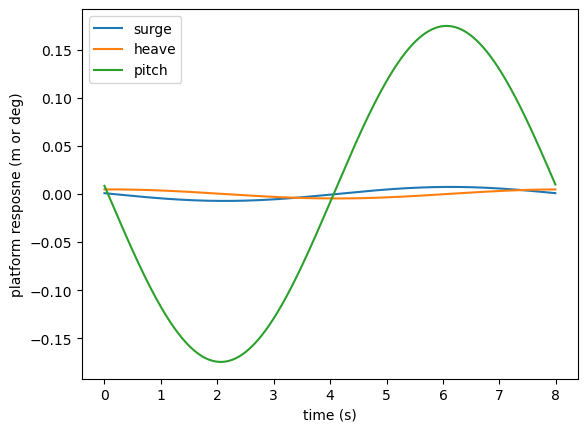

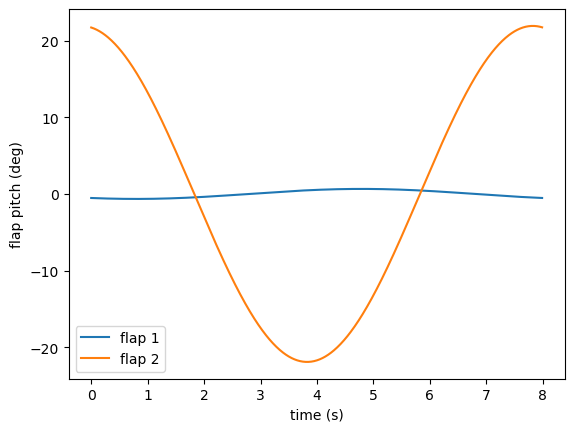

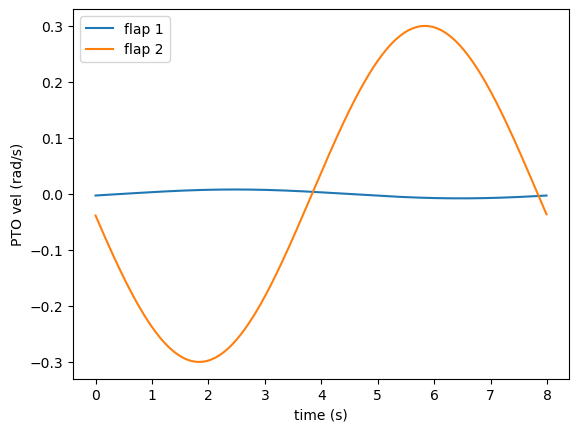

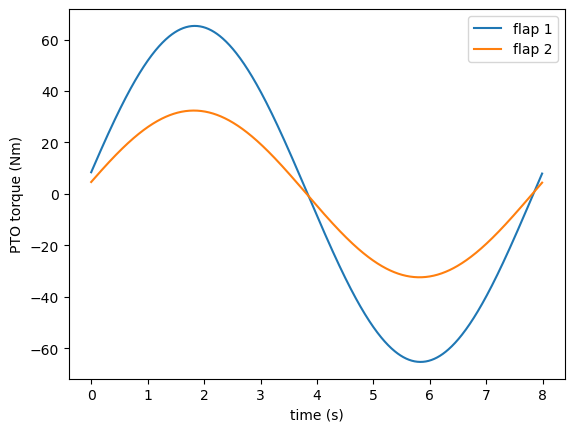

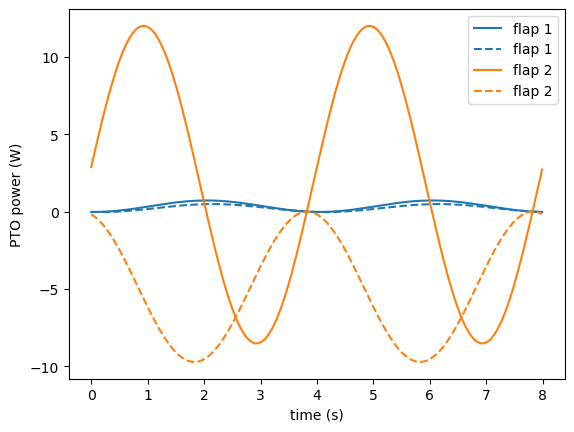

In [10]:
x_wec, x_opt = wec.decompose_state(results[0].x)
B = jnp.reshape(x_opt, (pto.ndof, pto.ndof))
print(f'Optimal damping matrix: {B}')

plt.figure()
plt.plot(wec_tdom_full['time'], wec_tdom_full.sel(realization=0).pos[0,:], label='surge')
plt.plot(wec_tdom_full['time'], wec_tdom_full.sel(realization=0).pos[1,:], label='heave')
plt.plot(wec_tdom_full['time'], wec_tdom_full.sel(realization=0).pos[2,:]*180/np.pi, label='pitch')
plt.xlabel('time (s)')
plt.ylabel('platform resposne (m or deg)')
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time'], wec_tdom_full.sel(realization=0).pos[5,:]*180/np.pi, label='flap 1')
plt.plot(wec_tdom_full['time'], wec_tdom_full.sel(realization=0).pos[8,:]*180/np.pi, label='flap 2')
plt.xlabel('time (s)')
plt.ylabel('flap pitch (deg)')
plt.legend()

plt.figure()
plt.plot(pto_tdom['time'], pto_tdom['vel'][0,:,0], label='flap 1')
plt.plot(pto_tdom['time'], pto_tdom['vel'][0,:,1], label='flap 2')
plt.xlabel('time (s)')
plt.ylabel('PTO vel (rad/s)')
plt.legend()

plt.figure()
plt.plot(pto_tdom['time'], pto_tdom['force'][0,:,0], label='flap 1')
plt.plot(pto_tdom['time'], pto_tdom['force'][0,:,1], label='flap 2')
plt.xlabel('time (s)')
plt.ylabel('PTO torque (Nm)')
plt.legend()

plt.figure()
plt.plot(pto_tdom['time'], pto_tdom['power'][0,:,:,0].sel(type='elec'), label='flap 1')
plt.plot(pto_tdom['time'], pto_tdom['power'][0,:,:,0].sel(type='mech'), '--', color='C0', label='flap 1')
plt.plot(pto_tdom['time'], pto_tdom['power'][0,:,:,1].sel(type='elec'), label='flap 2')
plt.plot(pto_tdom['time'], pto_tdom['power'][0,:,:,1].sel(type='mech'), '--', color='C1', label='flap 2')
plt.xlabel('time (s)')
plt.ylabel('PTO power (W)')
plt.legend()

avg_power = np.mean(pto_tdom['power'][0,0,:,0] + pto_tdom['power'][0,0,:,1]).values
print(f'Total avg power: {avg_power} W')